# Classifição - Machine Learning

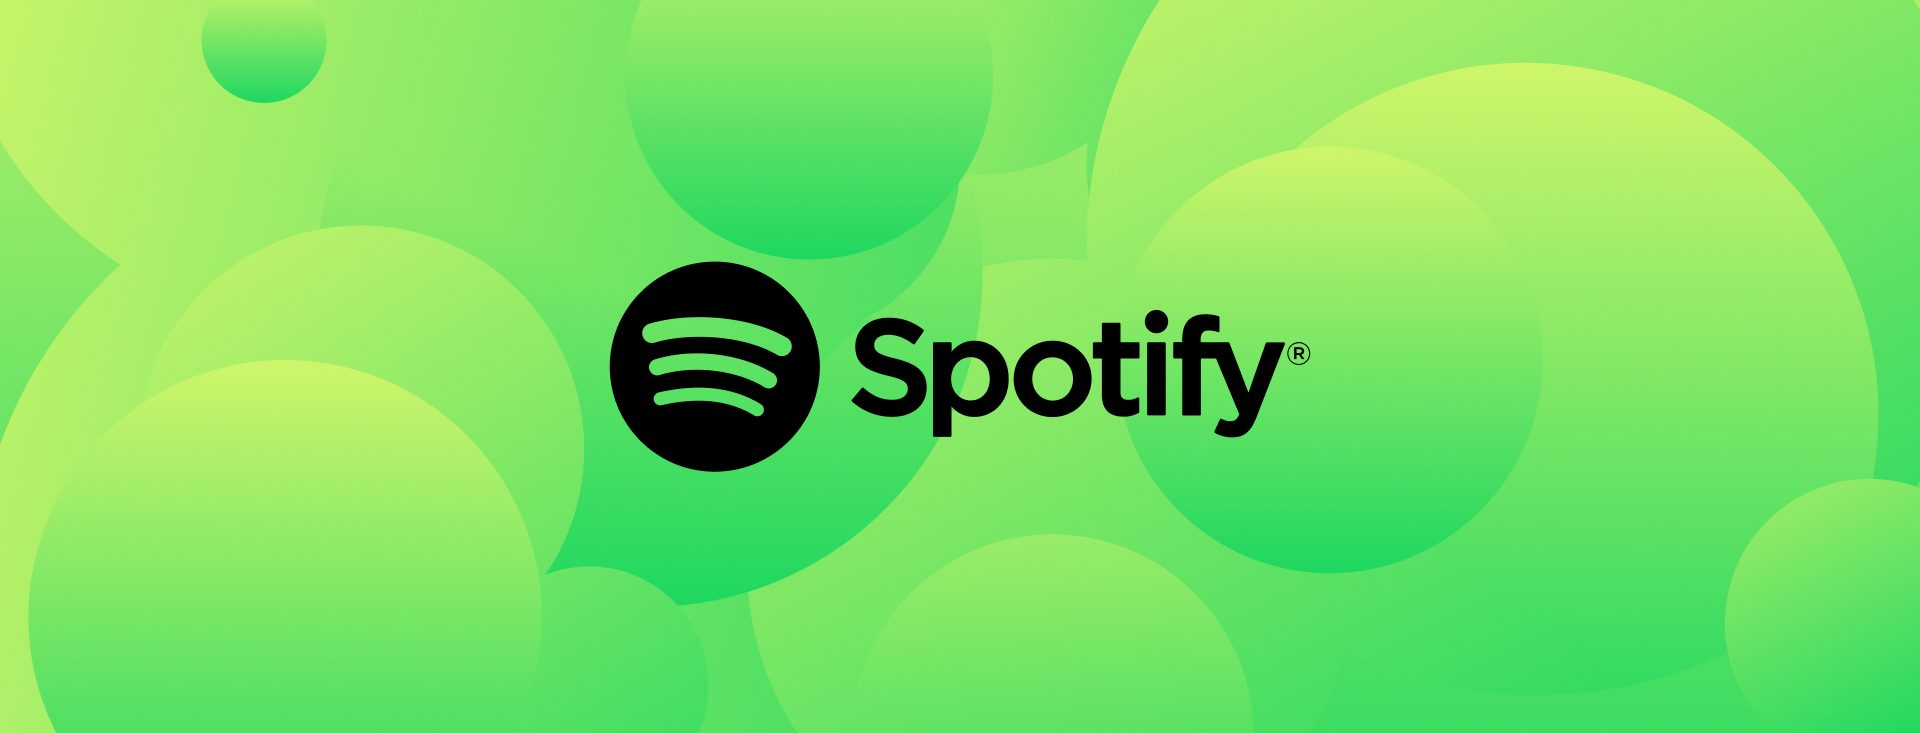

## Análise exploratória de dados - Distribuição do target

In [150]:
import pandas as pd
import numpy as np 
import seaborn as sns
import matplotlib.pyplot as plt

In [151]:
path_90 = "C:/Users/bianc/OneDrive/Documents/1-Estudos/2-DNC/1-Data Science/1-Material/Materis9-Modelos_de_Classificacao_Regressao/Classificacao/Classificacao-main/Datasets/The Spotify"
path_00 = "C:/Users/bianc/OneDrive/Documents/1-Estudos/2-DNC/1-Data Science/1-Material/Materis9-Modelos_de_Classificacao_Regressao/Classificacao/Classificacao-main/Datasets/The Spotify"
path_10 = "C:/Users/bianc/OneDrive/Documents/1-Estudos/2-DNC/1-Data Science/1-Material/Materis9-Modelos_de_Classificacao_Regressao/Classificacao/Classificacao-main/Datasets/The Spotify"


In [152]:
f"{path_90}/dataset-of-90s.csv"

'C:/Users/bianc/OneDrive/Documents/1-Estudos/2-DNC/1-Data Science/1-Material/Materis9-Modelos_de_Classificacao_Regressao/Classificacao/Classificacao-main/Datasets/The Spotify/dataset-of-90s.csv'

In [153]:
f"{path_00}/dataset-of-00s.csv"

'C:/Users/bianc/OneDrive/Documents/1-Estudos/2-DNC/1-Data Science/1-Material/Materis9-Modelos_de_Classificacao_Regressao/Classificacao/Classificacao-main/Datasets/The Spotify/dataset-of-00s.csv'

In [154]:
f"{path_10}/dataset-of-10s.csv"

'C:/Users/bianc/OneDrive/Documents/1-Estudos/2-DNC/1-Data Science/1-Material/Materis9-Modelos_de_Classificacao_Regressao/Classificacao/Classificacao-main/Datasets/The Spotify/dataset-of-10s.csv'

In [155]:
df_90 = pd.read_csv(f"{path_90}/dataset-of-90s.csv")
df_00 = pd.read_csv(f"{path_00}/dataset-of-00s.csv")
df_10 = pd.read_csv(f"{path_10}/dataset-of-10s.csv")

In [156]:
df = pd.concat([df_90, df_00, df_10])

In [157]:
df.head()

,track,artist,uri,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,duration_ms,time_signature,chorus_hit,sections,target
0,Misty Roses,Astrud Gilberto,spotify:track:50RBM1j1Dw7WYmsGsWg9Tm,0.527,0.316,1,-15.769,1,0.0310,0.693000,0.00699,0.1680,0.543,116.211,158840,4,53.89523,6,0
1,Never Ever,All Saints,spotify:track:5FTz9qQ94PyUHETyAyfYZN,0.738,0.541,1,-5.485,1,0.0311,0.559000,0.00000,0.0492,0.309,134.187,387573,4,32.16853,16,1
2,Soul Sermon,Gregg Karukas,spotify:track:6m24oe3lk1UMxq9zq4iPFi,0.736,0.419,0,-10.662,1,0.0300,0.693000,0.49500,0.0809,0.265,93.982,237267,4,42.05369,9,0
3,Clarinet Marmalade - Live,Alton Purnell,spotify:track:5FOXuiLI6knVtgMUjWKj6x,0.565,0.594,5,-13.086,1,0.0646,0.655000,0.92600,0.6750,0.763,114.219,375933,4,80.99693,10,0
4,До смерті і довше - Drum & Base and Rock Remix,Skryabin,spotify:track:6CxyIPTqSPvAPXfrIZczs4,0.513,0.760,4,-10.077,1,0.0355,0.000017,0.00339,0.1530,0.961,153.166,430653,4,25.57331,20,0


In [158]:
df.shape

(17790, 19)

In [159]:
df["target"].isnull().sum()

np.int64(0)

In [160]:
df["target"].value_counts()

target
0    8895
1    8895
Name: count, dtype: int64

In [161]:
df["target"].value_counts(normalize=True) * 100

target
0    50.0
1    50.0
Name: proportion, dtype: float64

In [162]:
df.drop_duplicates().shape

(17617, 19)

In [163]:
df = df.drop_duplicates()

In [164]:
df["target"].value_counts()

target
0    8895
1    8722
Name: count, dtype: int64

In [165]:
df["target"].value_counts(normalize=True) * 100

target
0    50.491003
1    49.508997
Name: proportion, dtype: float64

In [166]:
df.groupby(["track", "artist"]).size().sort_values(ascending=False)

track                                    artist            
Falling                                  Julee Cruise          12
Chebika - Claudio Mate Metal Remix       Stefano Patarnello     8
Feeling Punk - Asle Remix                Todd Terry             6
Spiegel im Spiegel                       Arvo Pärt              5
Until the Day I Die                      Story Of The Year      5
                                                               ..
(Do Not Feed The) Oyster                 Stephen Malkmus        1
(Everything I Do) I Do It For You        Bryan Adams            1
(Friday Afternoon) In a Galaxy Far Away  Mattias IA Eklundh     1
(Got My) Rock Pants On                   Turing Machine         1
(Hot S**t) Country Grammar               Nelly                  1
Length: 17362, dtype: int64

In [167]:
df = df.drop_duplicates(subset=["track", "artist"])

In [168]:
df.shape

(17362, 19)

In [169]:
df["target"].value_counts(normalize=True) * 100

target
1    50.224628
0    49.775372
Name: proportion, dtype: float64

## Análise exploratória de dados - Análise das features


In [170]:
df.head()

,track,artist,uri,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,duration_ms,time_signature,chorus_hit,sections,target
0,Misty Roses,Astrud Gilberto,spotify:track:50RBM1j1Dw7WYmsGsWg9Tm,0.527,0.316,1,-15.769,1,0.0310,0.693000,0.00699,0.1680,0.543,116.211,158840,4,53.89523,6,0
1,Never Ever,All Saints,spotify:track:5FTz9qQ94PyUHETyAyfYZN,0.738,0.541,1,-5.485,1,0.0311,0.559000,0.00000,0.0492,0.309,134.187,387573,4,32.16853,16,1
2,Soul Sermon,Gregg Karukas,spotify:track:6m24oe3lk1UMxq9zq4iPFi,0.736,0.419,0,-10.662,1,0.0300,0.693000,0.49500,0.0809,0.265,93.982,237267,4,42.05369,9,0
3,Clarinet Marmalade - Live,Alton Purnell,spotify:track:5FOXuiLI6knVtgMUjWKj6x,0.565,0.594,5,-13.086,1,0.0646,0.655000,0.92600,0.6750,0.763,114.219,375933,4,80.99693,10,0
4,До смерті і довше - Drum & Base and Rock Remix,Skryabin,spotify:track:6CxyIPTqSPvAPXfrIZczs4,0.513,0.760,4,-10.077,1,0.0355,0.000017,0.00339,0.1530,0.961,153.166,430653,4,25.57331,20,0


In [171]:
df.dtypes

track                object
artist               object
uri                  object
danceability        float64
energy              float64
key                   int64
loudness            float64
mode                  int64
speechiness         float64
acousticness        float64
instrumentalness    float64
liveness            float64
valence             float64
tempo               float64
duration_ms           int64
time_signature        int64
chorus_hit          float64
sections              int64
target                int64
dtype: object

In [172]:
df.isnull().sum()

track               0
artist              0
uri                 0
danceability        0
energy              0
key                 0
loudness            0
mode                0
speechiness         0
acousticness        0
instrumentalness    0
liveness            0
valence             0
tempo               0
duration_ms         0
time_signature      0
chorus_hit          0
sections            0
target              0
dtype: int64

In [173]:
df.describe()

,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,duration_ms,time_signature,chorus_hit,sections,target
count,17362.000000,17362.000000,17362.000000,17362.000000,17362.000000,17362.000000,17362.000000,17362.000000,17362.000000,17362.000000,17362.000000,1.736200e+04,17362.000000,17362.000000,17362.000000,17362.000000
mean,0.559860,0.655534,5.269036,-8.368586,0.652632,0.088807,0.240249,0.157978,0.196683,0.485989,121.053226,2.494776e+05,3.923050,40.964088,10.795473,0.502246
std,0.187469,0.246079,3.563331,5.302304,0.476148,0.092832,0.307832,0.308222,0.167195,0.255124,29.909889,1.119149e+05,0.378197,19.964160,4.744401,0.500009
min,0.057600,0.000251,0.000000,-49.253000,0.000000,0.022000,0.000000,0.000000,0.013000,0.000000,34.535000,1.592000e+04,0.000000,0.000000,1.000000,0.000000
25%,0.438000,0.505000,2.000000,-9.919000,0.000000,0.035700,0.009080,0.000000,0.093800,0.278250,97.149000,1.997632e+05,4.000000,27.902563,8.000000,0.000000
50%,0.577000,0.699000,5.000000,-6.913500,1.000000,0.050400,0.082700,0.000044,0.128000,0.487000,119.876000,2.331265e+05,4.000000,36.271890,10.000000,1.000000
75%,0.697000,0.856000,8.000000,-5.036000,1.000000,0.096700,0.378750,0.058800,0.257000,0.690000,140.003000,2.763132e+05,4.000000,48.324433,12.000000,1.000000
max,0.986000,0.999000,11.000000,1.137000,1.000000,0.956000,0.996000,0.998000,0.992000,0.996000,217.872000,4.170227e+06,5.000000,262.615400,169.000000,1.000000


In [174]:
## sns.pairplot(df.sample(1000), hue="target")

In [175]:
corr = df.select_dtypes('number').corr()

In [176]:
corr

,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,duration_ms,time_signature,chorus_hit,sections,target
danceability,1.000000,0.079547,0.020302,0.267515,-0.056397,0.187636,-0.194841,-0.349111,-0.109281,0.535457,-0.118716,-0.115242,0.177744,-0.066383,-0.090907,0.431556
energy,0.079547,1.000000,0.021120,0.773543,-0.008728,0.131180,-0.733336,-0.249619,0.201618,0.291144,0.206553,-0.088570,0.172705,-0.006720,-0.132499,0.117765
key,0.020302,0.021120,1.000000,0.007618,-0.153838,0.027905,-0.022199,-0.017270,-0.002199,0.019862,-0.003238,0.009676,-0.002717,0.003174,0.001698,0.018331
loudness,0.267515,0.773543,0.007618,1.000000,0.016656,0.114683,-0.641656,-0.453169,0.105401,0.279348,0.166995,-0.131400,0.181857,-0.037466,-0.152349,0.325587
mode,-0.056397,-0.008728,-0.153838,0.016656,1.000000,-0.078042,0.021148,-0.052902,0.003108,-0.001089,0.024613,-0.049147,0.009249,-0.020418,-0.037367,0.037270
speechiness,0.187636,0.131180,0.027905,0.114683,-0.078042,1.000000,-0.106344,-0.125366,0.137592,0.072458,0.037671,-0.029736,0.037711,-0.003131,-0.020936,0.070972
acousticness,-0.194841,-0.733336,-0.022199,-0.641656,0.021148,-0.106344,1.000000,0.282381,-0.097353,-0.177628,-0.159021,0.051123,-0.178735,0.009614,0.093083,-0.260632
instrumentalness,-0.349111,-0.249619,-0.017270,-0.453169,-0.052902,-0.125366,0.282381,1.000000,-0.039401,-0.296400,-0.040159,0.138729,-0.113558,0.082667,0.099897,-0.467519
liveness,-0.109281,0.201618,-0.002199,0.105401,0.003108,0.137592,-0.097353,-0.039401,1.000000,-0.010216,0.034006,0.000114,0.017876,0.045560,-0.024413,-0.081944
valence,0.535457,0.291144,0.019862,0.279348,-0.001089,0.072458,-0.177628,-0.296400,-0.010216,1.000000,0.039768,-0.174687,0.140427,-0.070973,-0.130453,0.214187


<Axes: >

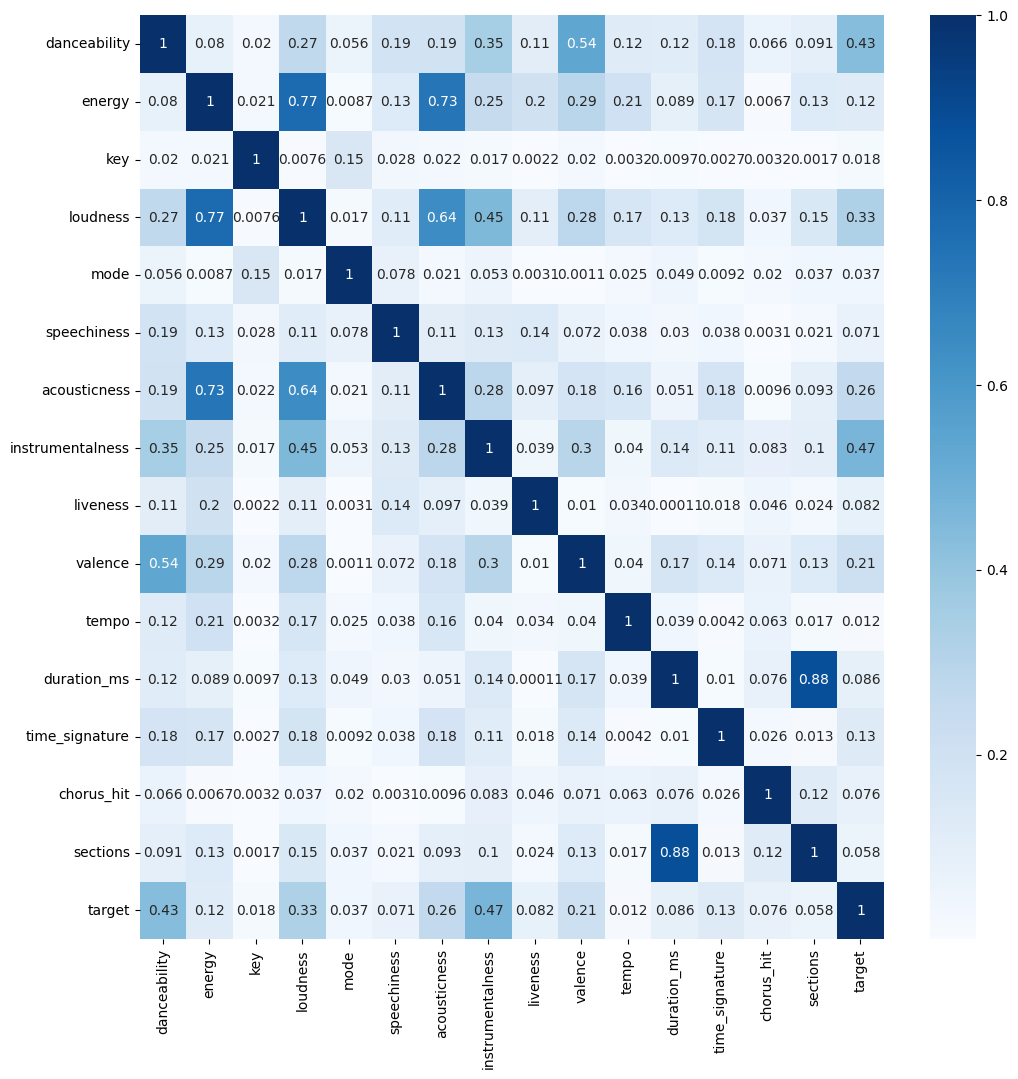

In [177]:
fig, ax = plt.subplots(figsize=(12, 12))
sns.heatmap(corr.abs(), cmap="Blues", annot=True)

## Separação dos dados - Features e Target


In [178]:
df.columns

Index(['track', 'artist', 'uri', 'danceability', 'energy', 'key', 'loudness',
       'mode', 'speechiness', 'acousticness', 'instrumentalness', 'liveness',
       'valence', 'tempo', 'duration_ms', 'time_signature', 'chorus_hit',
       'sections', 'target'],
      dtype='object')

In [179]:
features = ['danceability', 'energy', 'key', 'loudness',
       'mode', 'speechiness', 'acousticness', 'instrumentalness', 'liveness',
       'valence', 'tempo', 'duration_ms', 'time_signature', 'chorus_hit',
       'sections']

target = "target"

In [180]:
'''

X = df.drop(["track",	"artist",	"uri", "target"], axis=1)
y = df["target"]

'''

'\n\nX = df.drop(["track",\t"artist",\t"uri", "target"], axis=1)\ny = df["target"]\n\n'

In [181]:
X = df[features]
y = df[target]

In [182]:
X.shape, y.shape

((17362, 15), (17362,))

In [183]:

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, shuffle=True)

print("Features X_train: ", X_train.shape)
print("Features X_test: ", X_test.shape)
print("Target y_train: ", y_train.shape)
print("Target y_test: ", y_test.shape)

Features X_train:  (12153, 15)
Features X_test:  (5209, 15)
Target y_train:  (12153,)
Target y_test:  (5209,)


In [184]:
X_val, X_test, y_val, y_test = train_test_split(X_test, y_test, test_size=0.5, random_state=42, shuffle=True)

print("Features X_val: ", X_val.shape)
print("Features X_test: ", X_test.shape)
print("Target y_val: ", y_val.shape)
print("Target y_test: ", y_test.shape)

Features X_val:  (2604, 15)
Features X_test:  (2605, 15)
Target y_val:  (2604,)
Target y_test:  (2605,)


## Validação Cruzada (k-Fold)

In [185]:
from sklearn.model_selection import KFold

kfold = KFold(n_splits= 5, shuffle=True, random_state=42)

In [186]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, shuffle=True)

In [187]:
for train_index, test_index in kfold.split(X_train):
    X_train_fold = X_train.iloc[train_index]
    y_train_fold = y_train.iloc[train_index]
    
    X_test_fold = X_train.iloc[test_index]
    y_test_fold = y_train.iloc[test_index]

In [188]:
from sklearn.model_selection import cross_val_score

In [189]:
model = ...  # Defina seu modelo aqui



## Métricas de avaliação - Precision, Recall e F1-Score

In [190]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

y_true = [1, 0, 1, 1, 0, 1, 0, 1, 0, 0]  # Valores reais
y_pred = [1, 0, 1, 0, 0, 1, 0, 0, 0, 1]  # Valores previstos


In [191]:
accuracy = accuracy_score(y_true, y_pred)
precision = precision_score(y_true, y_pred)
recall = recall_score(y_true, y_pred)
f1 = f1_score(y_true, y_pred)

"""## Métricas de avaliação - Precision, Recall e F1-Score"""
print(f"Accuracy: {accuracy:.2f}")
print(f"Precision: {precision:.2f}")
print(f"Recall: {recall:.2f}")
print(f"F1 Score: {f1:.2f}")

Accuracy: 0.70
Precision: 0.75
Recall: 0.60
F1 Score: 0.67


In [192]:
from sklearn.metrics import confusion_matrix

Text(0.5, 1.0, 'Confusion Matrix')

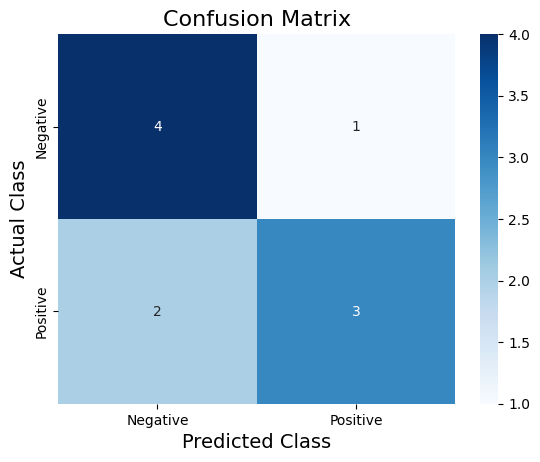

In [193]:
cm = confusion_matrix(y_true, y_pred)

ax = sns.heatmap(cm, cmap="Blues", annot=True, xticklabels=["Negative", "Positive"], yticklabels=["Negative", "Positive"])
            
plt.xlabel('Predicted Class', fontsize=14)
plt.ylabel('Actual Class', fontsize=14)
plt.title('Confusion Matrix', fontsize=16)

## Modelagem

### Pré-processamento

In [194]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
X_train = pd.DataFrame(scaler.fit_transform(X_train), columns=X.columns)

'''
ou 

scaler.fit_transform(X_train)
scaler.transform(X_train)

'''

'\nou \n\nscaler.fit_transform(X_train)\nscaler.transform(X_train)\n\n'

In [195]:
X_train.head()

,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,duration_ms,time_signature,chorus_hit,sections
0,0.347264,0.454259,0.000000,0.785451,0.0,0.015203,0.758032,0.624248,0.256148,0.289157,0.214131,0.025285,0.75,0.149573,0.012658
1,0.188927,0.931908,0.818182,0.895841,1.0,0.069165,0.000011,0.000002,0.106557,0.152610,0.535666,0.065448,0.75,0.225498,0.056962
2,0.599311,0.543380,0.454545,0.851011,1.0,0.376874,0.007791,0.000033,0.379098,0.486948,0.778995,0.057407,0.75,0.176967,0.056962
3,0.755493,0.825764,0.727273,0.912247,1.0,0.211991,0.092671,0.000571,0.232582,0.430723,0.310852,0.045089,0.75,0.285022,0.050633
4,0.800732,0.543380,0.454545,0.807389,1.0,0.073876,0.566265,0.000000,0.105533,0.536145,0.530036,0.072918,0.75,0.331427,0.056962


In [196]:
X_test = pd.DataFrame(scaler.transform(X_test), columns=X.columns)

### Regressão Logística

In [197]:
from sklearn.linear_model import LogisticRegression

In [198]:
model = LogisticRegression(random_state=42)

In [199]:
model

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,42
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [200]:
model.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,42
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [201]:
y_pred = model.predict(X_test)

In [202]:
y_pred

array([0, 0, 0, ..., 0, 0, 0], shape=(5209,))

In [203]:
pd.Series(y_pred).value_counts()

1    3044
0    2165
Name: count, dtype: int64

In [204]:
pd.Series(y_pred).value_counts(normalize=True) * 100

1    58.43732
0    41.56268
Name: proportion, dtype: float64

In [205]:
accuracy = accuracy_score(y_test, y_pred)

In [206]:
accuracy

0.7928585141101939

In [207]:
from sklearn.metrics import classification_report

In [208]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.85      0.71      0.77      2606
           1       0.75      0.88      0.81      2603

    accuracy                           0.79      5209
   macro avg       0.80      0.79      0.79      5209
weighted avg       0.80      0.79      0.79      5209



### k-NN

In [209]:
from sklearn.neighbors import KNeighborsClassifier

In [210]:
model = KNeighborsClassifier()

In [211]:
model.fit(X_train, y_train)

,n_neighbors,5
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


In [212]:
y_pred = model.predict(X_test)

In [213]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.83      0.71      0.76      2606
           1       0.75      0.86      0.80      2603

    accuracy                           0.78      5209
   macro avg       0.79      0.78      0.78      5209
weighted avg       0.79      0.78      0.78      5209



In [214]:
model = KNeighborsClassifier(n_neighbors=3)

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

accuracy_score(y_test, y_pred)

0.7669418314455749

In [215]:
model = KNeighborsClassifier(n_neighbors=7)

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

accuracy_score(y_test, y_pred)

0.7880591284315608

### Árvore de Decisão

In [216]:
from sklearn.tree import DecisionTreeClassifier

In [217]:
model = DecisionTreeClassifier(random_state=42)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.75      0.75      0.75      2606
           1       0.75      0.76      0.75      2603

    accuracy                           0.75      5209
   macro avg       0.75      0.75      0.75      5209
weighted avg       0.75      0.75      0.75      5209



In [218]:
model = DecisionTreeClassifier(random_state=42, criterion='entropy')
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.76      0.76      0.76      2606
           1       0.76      0.76      0.76      2603

    accuracy                           0.76      5209
   macro avg       0.76      0.76      0.76      5209
weighted avg       0.76      0.76      0.76      5209



In [219]:
y_pred_train = model.predict(X_train)
print(classification_report(y_train, y_pred_train))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00      6036
           1       1.00      1.00      1.00      6117

    accuracy                           1.00     12153
   macro avg       1.00      1.00      1.00     12153
weighted avg       1.00      1.00      1.00     12153



In [220]:
model = DecisionTreeClassifier(random_state=42, criterion='entropy', max_depth=7)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.85      0.76      0.80      2606
           1       0.78      0.86      0.82      2603

    accuracy                           0.81      5209
   macro avg       0.81      0.81      0.81      5209
weighted avg       0.81      0.81      0.81      5209



In [221]:
y_pred_train = model.predict(X_train)
print(classification_report(y_train, y_pred_train))

              precision    recall  f1-score   support

           0       0.86      0.78      0.82      6036
           1       0.80      0.88      0.84      6117

    accuracy                           0.83     12153
   macro avg       0.83      0.83      0.83     12153
weighted avg       0.83      0.83      0.83     12153



### Random Forest

In [222]:
from sklearn.ensemble import RandomForestClassifier

In [223]:
model = RandomForestClassifier(random_state=42)

model.fit(X_train, y_train)
y_pred = model.predict(X_test)

In [224]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.86      0.79      0.82      2606
           1       0.81      0.88      0.84      2603

    accuracy                           0.83      5209
   macro avg       0.83      0.83      0.83      5209
weighted avg       0.83      0.83      0.83      5209



In [225]:
model = RandomForestClassifier(random_state=42, n_estimators=200, max_depth=10) ### padrão n_estimators=100

model.fit(X_train, y_train)
y_pred = model.predict(X_test)

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.88      0.76      0.82      2606
           1       0.79      0.89      0.84      2603

    accuracy                           0.83      5209
   macro avg       0.83      0.83      0.83      5209
weighted avg       0.83      0.83      0.83      5209



In [226]:
model = RandomForestClassifier(random_state=42, n_estimators=50, max_depth=20)

model.fit(X_train, y_train)
y_pred = model.predict(X_test)

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.87      0.78      0.82      2606
           1       0.80      0.88      0.84      2603

    accuracy                           0.83      5209
   macro avg       0.84      0.83      0.83      5209
weighted avg       0.84      0.83      0.83      5209



In [227]:
model = RandomForestClassifier(random_state=42, n_estimators=20, max_depth=50)

model.fit(X_train, y_train)
y_pred = model.predict(X_test)

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.84      0.80      0.82      2606
           1       0.81      0.85      0.83      2603

    accuracy                           0.83      5209
   macro avg       0.83      0.83      0.83      5209
weighted avg       0.83      0.83      0.83      5209



### Gradient Boosting

In [228]:
from sklearn.ensemble import GradientBoostingClassifier

In [229]:
model = GradientBoostingClassifier(random_state=42)
model.fit(X_train, y_train)

,loss,'log_loss'
,learning_rate,0.1
,n_estimators,100
,subsample,1.0
,criterion,'friedman_mse'
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_depth,3
,min_impurity_decrease,0.0
,init,None


In [230]:
y_pred = model.predict(X_test)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.87      0.77      0.82      2606
           1       0.79      0.89      0.84      2603

    accuracy                           0.83      5209
   macro avg       0.83      0.83      0.83      5209
weighted avg       0.83      0.83      0.83      5209



In [231]:
model = GradientBoostingClassifier(random_state=42, n_estimators=200)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.87      0.78      0.82      2606
           1       0.80      0.89      0.84      2603

    accuracy                           0.83      5209
   macro avg       0.84      0.83      0.83      5209
weighted avg       0.84      0.83      0.83      5209



In [232]:
model = GradientBoostingClassifier(random_state=42, learning_rate=0.5)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.86      0.78      0.82      2606
           1       0.80      0.87      0.83      2603

    accuracy                           0.82      5209
   macro avg       0.83      0.82      0.82      5209
weighted avg       0.83      0.82      0.82      5209



In [233]:
model = GradientBoostingClassifier(random_state=42, subsample=0.5)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.88      0.78      0.83      2606
           1       0.80      0.89      0.85      2603

    accuracy                           0.84      5209
   macro avg       0.84      0.84      0.84      5209
weighted avg       0.84      0.84      0.84      5209



### Redes Neurais (MLP)

In [234]:
from sklearn.neural_network import MLPClassifier

In [235]:
model = MLPClassifier(random_state=42)
model.fit(X_train, y_train)

c:\Users\bianc\.venv\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(


,hidden_layer_sizes,"(100,)"
,activation,'relu'
,solver,'adam'
,alpha,0.0001
,batch_size,'auto'
,learning_rate,'constant'
,learning_rate_init,0.001
,power_t,0.5
,max_iter,200
,shuffle,True
,random_state,42


In [236]:
y_pred = model.predict(X_test)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.88      0.76      0.81      2606
           1       0.79      0.90      0.84      2603

    accuracy                           0.83      5209
   macro avg       0.83      0.83      0.83      5209
weighted avg       0.83      0.83      0.83      5209



In [237]:
model = MLPClassifier(hidden_layer_sizes=(100, 100), random_state=42)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.87      0.78      0.82      2606
           1       0.80      0.88      0.84      2603

    accuracy                           0.83      5209
   macro avg       0.83      0.83      0.83      5209
weighted avg       0.83      0.83      0.83      5209



c:\Users\bianc\.venv\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(


In [ ]:
model = MLPClassifier(hidden_layer_sizes=(100,100), activation="tanh", random_state=42)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
print(classification_report(y_test, y_pred))

In [ ]:
from sklearn.metrics import roc_curve, auc

In [ ]:
model.predict_proba(X_test)

array([[0.97984412, 0.02015588],
       [0.61502089, 0.38497911],
       [0.95599971, 0.04400029],
       ...,
       [0.93828566, 0.06171434],
       [0.55299044, 0.44700956],
       [0.98509732, 0.01490268]], shape=(5209, 2))

In [ ]:
y_proba = model.predict_proba(X_test)

In [ ]:
# Obter as probabilidades de previsão
y_proba = model.predict_proba(X_test)[:, 1]  # Seleciona apenas a coluna com probabilidades da classe positiva

# Calcular a curva ROC
fpr, tpr, thresholds = roc_curve(y_test, y_proba)

In [ ]:
# Calcular AUC
roc_auc = auc(fpr, tpr)
print(f"AUC: {roc_auc:.4f}")

AUC: 0.8935


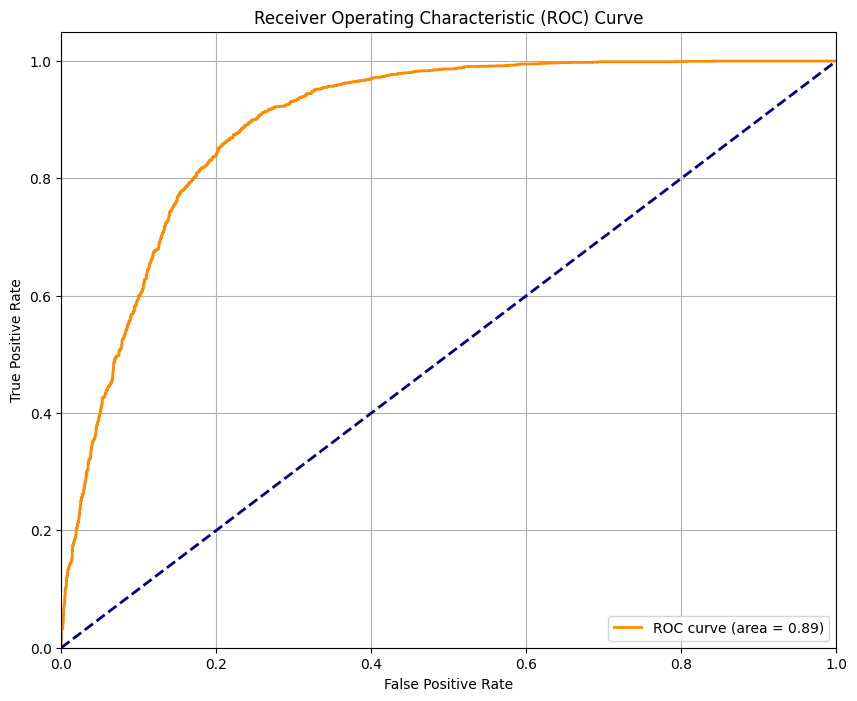

In [ ]:
# Plotar curva ROC
plt.figure(figsize=(10, 8))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

### Avaliação as interações ao longo do aprendizado da Rede Neural

In [ ]:
X_train, X_val, y_train, y_val  =  train_test_split(X_train, y_train, test_size=0.10, random_state=42)

In [ ]:
model = MLPClassifier(max_iter=1, warm_start=True, random_state=42)

max_iterations = 1000

accuracy_val_results = []   
accuracy_train_results = []

for iter in range(max_iterations):
    model.fit(X_train, y_train)
    
    y_pred_val = model.predict(X_val)
    y_pred_train = model.predict(X_train)
    
    accuracy_val = accuracy_score(y_val, y_pred_val)
    accuracy_val_results.append(accuracy_val)
    
    accuracy_train = accuracy_score(y_train, y_pred_train)
    accuracy_train_results.append(accuracy_train)

c:\Users\bianc\.venv\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1) reached and the optimization hasn't converged yet.
  warnings.warn(
c:\Users\bianc\.venv\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1) reached and the optimization hasn't converged yet.
  warnings.warn(
c:\Users\bianc\.venv\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1) reached and the optimization hasn't converged yet.
  warnings.warn(
c:\Users\bianc\.venv\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1) reached and the optimization hasn't converged yet.
  warnings.warn(
c:\Users\bianc\.venv\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:781: Con

In [ ]:
list(range(1, max_iterations +1))

[1,
 2,
 3,
 4,
 5,
 6,
 7,
 8,
 9,
 10,
 11,
 12,
 13,
 14,
 15,
 16,
 17,
 18,
 19,
 20,
 21,
 22,
 23,
 24,
 25,
 26,
 27,
 28,
 29,
 30,
 31,
 32,
 33,
 34,
 35,
 36,
 37,
 38,
 39,
 40,
 41,
 42,
 43,
 44,
 45,
 46,
 47,
 48,
 49,
 50,
 51,
 52,
 53,
 54,
 55,
 56,
 57,
 58,
 59,
 60,
 61,
 62,
 63,
 64,
 65,
 66,
 67,
 68,
 69,
 70,
 71,
 72,
 73,
 74,
 75,
 76,
 77,
 78,
 79,
 80,
 81,
 82,
 83,
 84,
 85,
 86,
 87,
 88,
 89,
 90,
 91,
 92,
 93,
 94,
 95,
 96,
 97,
 98,
 99,
 100,
 101,
 102,
 103,
 104,
 105,
 106,
 107,
 108,
 109,
 110,
 111,
 112,
 113,
 114,
 115,
 116,
 117,
 118,
 119,
 120,
 121,
 122,
 123,
 124,
 125,
 126,
 127,
 128,
 129,
 130,
 131,
 132,
 133,
 134,
 135,
 136,
 137,
 138,
 139,
 140,
 141,
 142,
 143,
 144,
 145,
 146,
 147,
 148,
 149,
 150,
 151,
 152,
 153,
 154,
 155,
 156,
 157,
 158,
 159,
 160,
 161,
 162,
 163,
 164,
 165,
 166,
 167,
 168,
 169,
 170,
 171,
 172,
 173,
 174,
 175,
 176,
 177,
 178,
 179,
 180,
 181,
 182,
 183,
 184,
 185

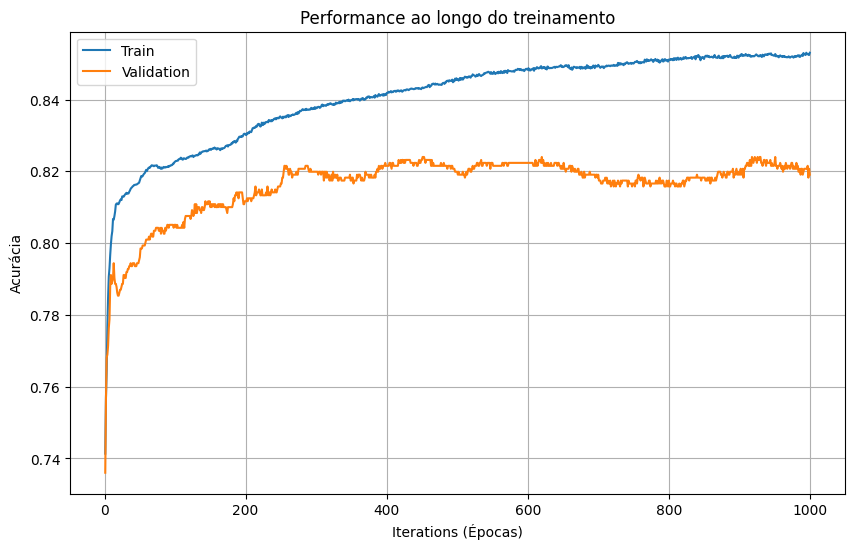

In [ ]:
plt.figure(figsize=(10, 6))

plt.plot(range(1, max_iterations +1), accuracy_train_results, label="Train")
plt.plot(range(1, max_iterations +1), accuracy_val_results, label="Validation")

plt.xlabel("Iterations (Épocas)")
plt.ylabel("Acurácia")
plt.title("Performance ao longo do treinamento")
plt.legend()
plt.grid(True)
plt.show()